In [4]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')


In [5]:
# 设置标的和日期
instrument_id = '518880'
trade_ymd = '20260319'

# 策略参数配置
param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_demo',
    'stride': 1,

    'short_window': 60,      # 短期窗口
    'long_window': 300,      # 长期窗口
    'y_window': 300,         # 标签窗口

    'open_threshold': 2,     # 开仓阈值
    'open_confidence': 0,    # 开仓置信度
    'close_confidence': 0.2, # 平仓置信度
    'standard_num': 1000,    # 标准数量

    'atr_multiplier': 4,     # 回撤比例
    'vol_window': 900,       # 价格波动窗口

    'k_up': 3,
    'k_down': 3,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

In [ ]:
model_path = f"/home/jovyan/work/model/delta_debug.pkl"
import joblib
model = joblib.load(model_path)
print(f"模型已加载: {model_path}")

模型已加载: /home/jovyan/work/model/delta_v2.pkl


In [ ]:
from delta import strategy 
tactic = strategy.StrategyDemo(model_path, param_dict)

In [15]:
snap_list = base_tool.snap_list_load(instrument_id, trade_ymd)

position_dict = {}
for snap in snap_list:
    tactic.on_snap(snap)
    position_dict[snap['time_mark']] = tactic.position_last


position_dict 时间错误 01:30:00
/home/jovyan/work/backtest_result/518880_20260319_delta_v1_demo.pkl 已超时


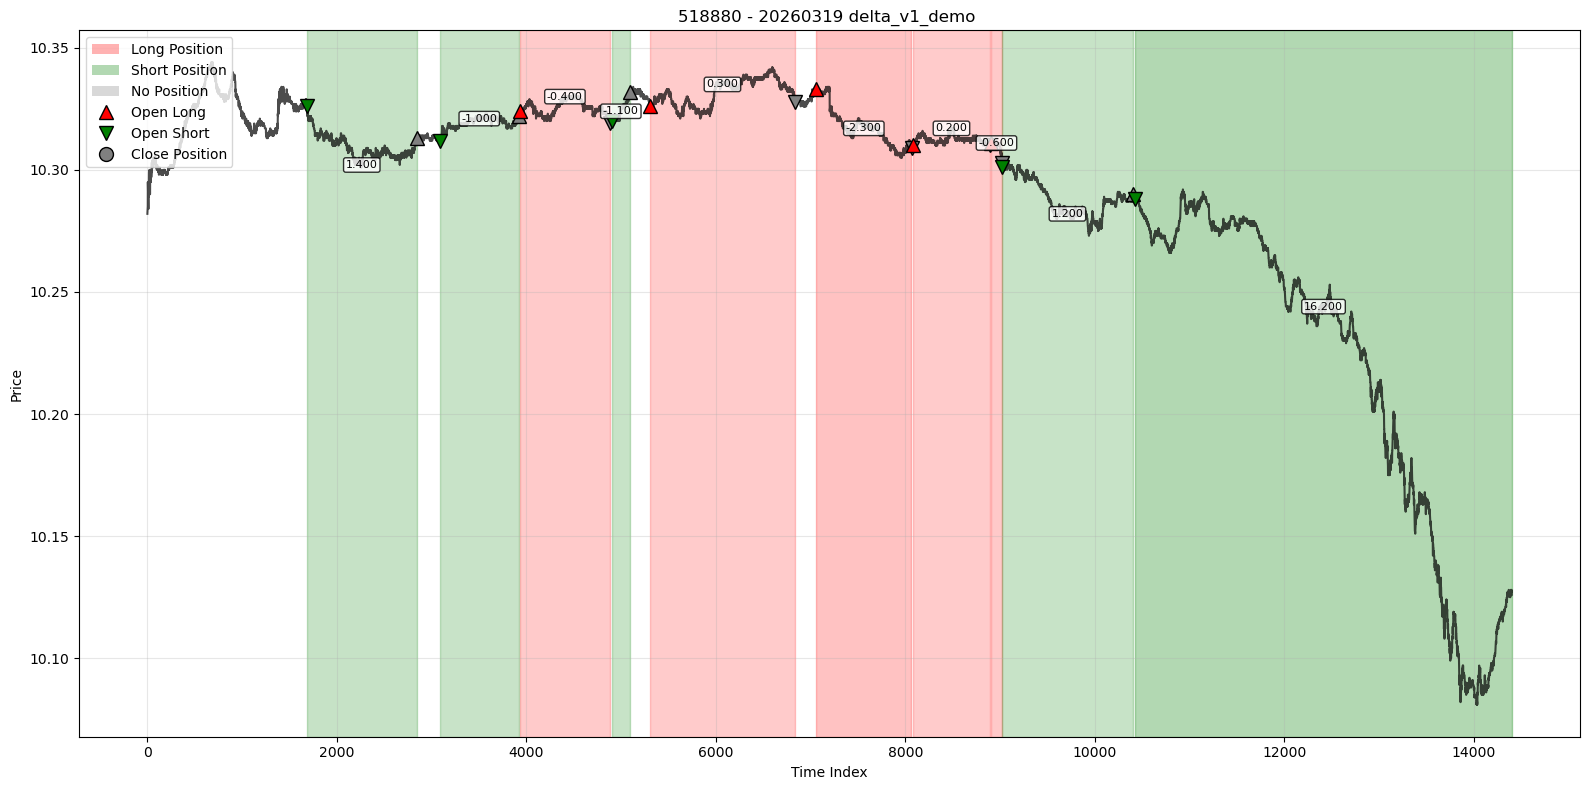

In [16]:
# 执行单日回测
import sys
sys.path.append('/home/jovyan/work/tactics_demo/tools')

from single_day_backtest import single_day_backtest

profit_df = single_day_backtest(
    instrument_id=instrument_id,
    trade_ymd=trade_ymd,
    StrategyClass=strategy.StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    official= True, 
)